In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import jax.random as jr
import blackjax

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


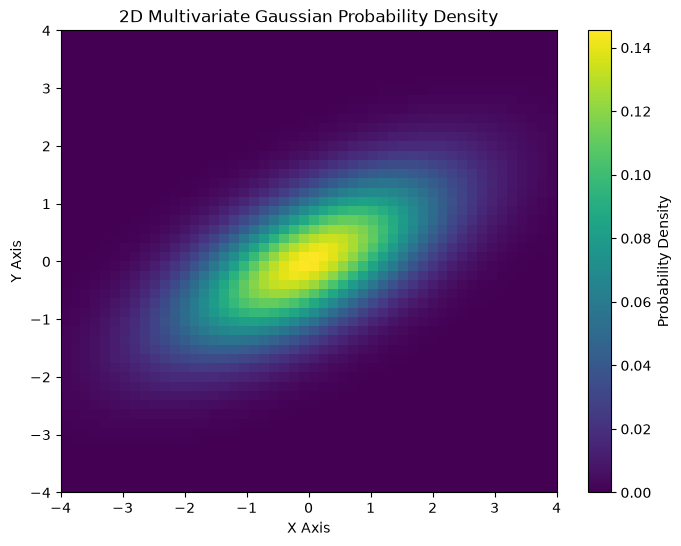

In [32]:
from scipy.stats import multivariate_normal
rng_key = jr.key(3);
cov_matrix = jnp.array([[2.0, 0.9],
                       [0.9, 1.0]])
mean = jnp.array([0.0, 0.0])
measurement_error_bar = 0.1;
# Measurement: e^x + e^y = 1 +\- 0.1
def log_density_fcn(x, y):
    v = jnp.array([x, y]);
    return -0.5*v.T @ jnp.linalg.inv(cov_matrix) @ v; 

logdensity = lambda x: log_density_fcn(**x)

rng, key = jr.split(rng_key)
noise = jr.normal(key, shape = (2, 10000))
L = jnp.linalg.cholesky(cov_matrix)
samples = L @ noise


x = jnp.linspace(-4, 4, 50)
y = jnp.linspace(-4, 4, 50)


X, Y = np.meshgrid(x, y)


pos = np.dstack((X, Y))

# 3. Compute the multivariate Gaussian PDF on the grid
rv = multivariate_normal(mean, cov_matrix)
Z = rv.pdf(pos)

# 4. Plot the heatmap
plt.figure(figsize=(8, 6))
# 'origin=lower' ensures the y-axis increases upwards
# 'cmap' sets the color palette (viridis, plasma, and inferno work great)
heatmap = plt.imshow(Z, extent=[-4, 4, -4, 4], origin='lower', cmap='viridis', aspect='auto')

# Add a colorbar, labels, and title
plt.colorbar(heatmap, label='Probability Density')
plt.title('2D Multivariate Gaussian Probability Density')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')

# Display the plot
plt.show()


In [33]:
inv_mass_matrix = cov_matrix;
num_integration_steps = 60
step_size = 1e-3

hmc = blackjax.hmc(logdensity, step_size, inv_mass_matrix, num_integration_steps)

initial_position = {"x": 0.0, "y": 0.0}
initial_state = hmc.init(initial_position)
initial_state

HMCState(position={'x': 0.0, 'y': 0.0}, logdensity=Array(0., dtype=float32), logdensity_grad={'x': Array(0., dtype=float32, weak_type=True), 'y': Array(0., dtype=float32, weak_type=True)})

In [34]:
hmc_kernel = jax.jit(hmc.step)

def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state, _ = kernel(rng_key, state)
        return state, state

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states



rng_key, sample_key = jax.random.split(rng_key)
states = inference_loop(sample_key, hmc_kernel, initial_state, 10)

mcmc_samples = states.position

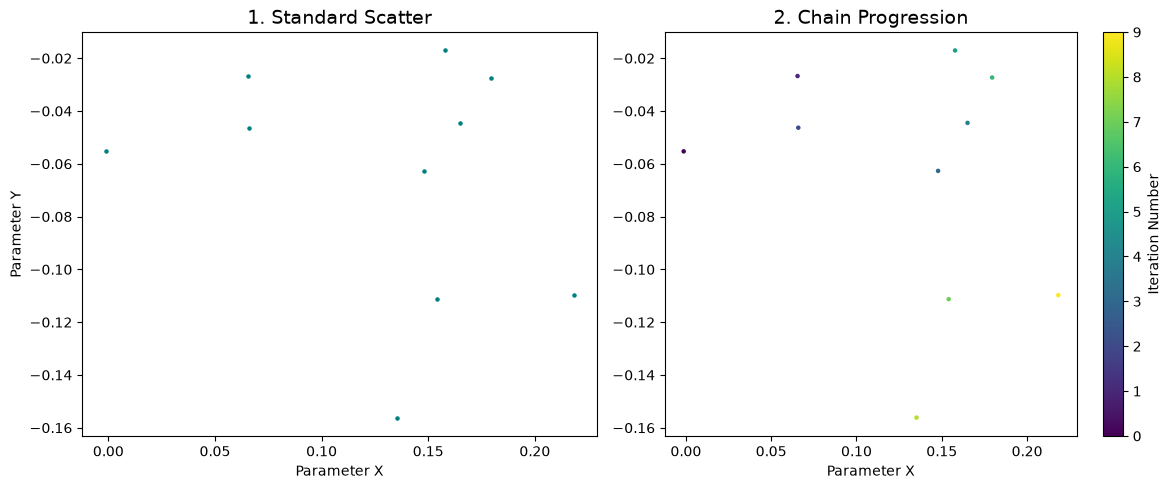

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(mcmc_samples["x"], mcmc_samples["y"], alpha=1, s=5, color='teal')
axes[0].set_title("1. Standard Scatter", fontsize=14)
axes[0].set_xlabel("Parameter X")
axes[0].set_ylabel("Parameter Y")

# ---------------------------------------------------------
# SUBPLOT 2: The Chain Progression (axes[1])
# ---------------------------------------------------------
iterations = np.arange(len(mcmc_samples["x"]))
scatter2 = axes[1].scatter(mcmc_samples["x"], mcmc_samples["y"], 
                           c=iterations, cmap='viridis', alpha=1, s=5)
axes[1].set_title("2. Chain Progression", fontsize=14)
axes[1].set_xlabel("Parameter X")
# For colorbars in subplots, you must tell it which axis to attach to
fig.colorbar(scatter2, ax=axes[1], label="Iteration Number") 

# 3. Final Polish and Display
plt.tight_layout() # Prevents overlapping text/labels between the plots
plt.show()

How does HMC work on a broad level and what is the motiavtion behind it? In the problem of Bayseian Inference, we know that $$P(q|d) = \frac{P(d|q) \cdot P(q)}{P(d)}$$

Our goal is to find $P(q|d)$, the posterior. However, it is very very hard to integrate $P(d|q) \cdot P(q)$ to get $P(d)$ directly. So, we take samples from the posterior using Hamiltonian Monte Carlo. We introduce a "momentum" variable p and let $$\pi(p, q) = \pi(p | q) \cdot \pi(q)$$ be the probability density function for position and momentum in "phase space." We define $\pi(q) = P(d|q) \cdot P(q)$ (the unnormalized posterior density), and we usually let $\pi(p|q) \  \alpha \  e^{-0.5(P^TM^{-1}P)}$ (so that p and q are independent). $M^{-1}$ is the inverse mass matrix and usually equals the covariance of q, $E((q - \mu)^T(q - \mu))$. The Hamiltonian $H(p, q)$ is given by $H(p, q) = -\log(\pi(p, q)) = K(p, q) + V(q)$, where $K(p, q) = -\log(\pi(p | q))$ and $V(q) = -\log(\pi(q))$.

 We repeat the following steps:

1) Generate a random momentum by drawing from the momentum distrubtion $\pi(p|q) \  \alpha \  e^{-0.5(P^TM^{-1}P)}$
2) Integrate Hamilton's Equations: $$\frac{dq}{dt} = \frac{\partial H}{\partial p} = \frac{\partial K}{\partial p}$$ $$\frac{dp}{dt} = -\frac{\partial H}{\partial q} = -\frac{\partial K}{\partial q} -\frac{\partial V}{\partial q}$$

Usually, the $-\frac{\partial K}{\partial q}$ drops out of the second equation. To do so, we use the Leapfrog method; each step, we update momentum by 0.5, position by 1, and then finally momentum by 0.5 again. The length of time and number of steps we integrate for are constants. We generally want to explore most of the energy level set we are on.

3) If numerical integration was perfect, energy would be conserved and the integration would never change the probability distrubiton in phase space. However, since numerical integration is imperfect, energy may vary a little and we need to do the Metropolis-Hastings correction $$P(acceptance) = \min(1, \frac{e^{-H_(p', q')}}{e^{-H(p, q)}})$$ If we fail to accept our final point $(p', q')$, we go back to $(p, q)$. See note at the end.

4) Record the position $q$ we are at as one sample. (do not record intermediate positions in step 3)

In simplified form, Hamilton's equations usually are $$\frac{dq}{dt} = \frac{d(-0.5P^TM^{-1}P)}{dt} = M^{-1}P$$ and $$\frac{dp}{dt} = \frac{d(-\log(\pi(q)))}{dt}$$

Why does HMC leave the probability space $\pi(p, q)$ invariant? One key reason is that the probability of going from $(p, q)$ to $(p', q')$ is the same as the probability of going from $(p', q')$ to $(p, q)$. However, Hamilton's equations are reversible (reversing the momentum lets one trace the steps backwards) and symplectic (Hamilton's equations have a Jacobian of determinant 1; they preserve area). So, with the Metropolis-Hastings correction $P(acceptance) = \min(1, \frac{e^{-H_(p', q')}}{e^{-H(p, q)}})$, we get that $$\pi(p, q) \cdot P((p, q) \rightarrow (p', q')) = \min(e^{-H(p, q)}, e^{-H(p', q')}) = \pi(p', q') \cdot P((p', q') \rightarrow (p, q))$$

When picking a formula $\pi(p|q)$, we want the energy scale of the momentum $-\log(\pi(p|q))$ to match the energy scale of the position $-\log(\pi(q))$. Why? If the energy scale of the momentum is too low, it will take way too long to explore all of the energy level sets in the position/momentum distribution. 